# Task 2: NLP- Sentiment Analysis using NLP Pipeline & ML Models
### Using: IMDB Dataset

## 1. Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
# Check shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:", df.columns)

# Data types
print("\nData Types:\n", df.dtypes)

Shape of dataset: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Data Types:
 review       object
sentiment    object
dtype: object


In [3]:
# Missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 review       0
sentiment    0
dtype: int64


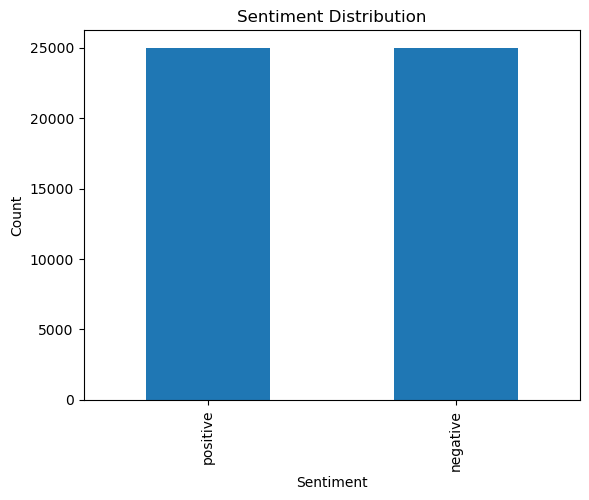

In [4]:
#Visualization
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [5]:
# Show sample reviews
print("\nSample Reviews:\n")
for i in range(3):
    print(f"Review {i+1}:")
    print(df['review'][i])
    print()


Sample Reviews:

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal o

## 2. NLP Preprocessing

In [6]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Ganesh
[nltk_data]     mandal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Ganesh
[nltk_data]     mandal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\Ganesh
[nltk_data]     mandal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ganesh
[nltk_data]     mandal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 5. Tokenization
    tokens = word_tokenize(text)
    
    # 6. Remove stopwords & Lemmatization
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            cleaned_tokens.append(word)
    
    # 7. Join back to sentence
    return " ".join(cleaned_tokens)


In [24]:
    # Apply Preprocessing
    df['cleaned_review'] = df['review'].apply(preprocess_text)

In [9]:
    # Compare
    print("Original Review:\n", df['review'][0])
    print("\nCleaned Review:\n", df['cleaned_review'][0])

Original Review:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

## 3. Feature Engineering (BoW + TF-IDF)

In [31]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")

df['sentiment'] = df['sentiment'].str.strip().str.lower()
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df['sentiment'].unique())
print("Missing:", df['sentiment'].isnull().sum())

df = df.dropna(subset=['sentiment'])

# ADD THIS LINE (THIS WAS MISSING)
df['cleaned_review'] = df['review'].apply(preprocess_text)

from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

[1 0]
Missing: 0


In [30]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [32]:
print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

TF-IDF Train Shape: (40000, 5000)
TF-IDF Test Shape: (10000, 5000)


In [33]:
print("BoW Train Shape:", X_train_bow.shape)
print("BoW Test Shape:", X_test_bow.shape)

BoW Train Shape: (40000, 5000)
BoW Test Shape: (10000, 5000)


## 4. Model Building

In [36]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train model
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_tfidf)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8848


In [37]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8519


In [39]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7198


## 5. Model Evaluation

In [40]:
# Evaluation
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes Report:\n")
print(classification_report(y_test, y_pred_nb))

print("\nDecision Tree Report:\n")
print(classification_report(y_test, y_pred_dt))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000


Naive Bayes Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Decision Tree Report:

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      4961
           1       0.73      0.71      0.72      5039

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000

## 6. Comparison & Insights

###  Comparison & Insights

- Logistic Regression achieved the highest accuracy and balanced performance across precision, recall, and F1-score.  
- Naive Bayes performed well and is computationally efficient but slightly less accurate than Logistic Regression.  
- Decision Tree showed lower performance due to overfitting and is not ideal for high-dimensional sparse text data.  
- TF-IDF vectorization improved performance by giving importance to meaningful words over frequent words.  
- Overall, Logistic Regression with TF-IDF is the best combination for this task.

###  Conclusion

- Built a complete NLP pipeline for sentiment analysis.  
- Applied preprocessing techniques like tokenization, stopword removal, and lemmatization.  
- Used feature engineering methods (BoW and TF-IDF).  
- Trained multiple machine learning models and compared their performance.  
- Logistic Regression gave the best results for this dataset.